# Choix du modele pour la prediction des ventes

Ce notebook documente la comparaison entre plusieurs modeles de regression et justifie le choix final.
Nous evaluons la performance predictive et la stabilite via validation croisee.

## Objectif
Predire les ventes (Sales) a partir des budgets marketing (TV, Radio, Social Media) et du type d'influenceur.
Le modele retenu doit etre precis, stable, et interpretable pour orienter les decisions marketing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

import sys
sys.path.insert(0, str(Path.cwd().parents[0]))

from src.preprocessing.preprocessing import get_preprocessed_data

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Donnees et preprocessing
On reutilise la pipeline de preprocessing officielle pour garantir la coherence entre entrainement et production.

In [2]:
x_train, x_test, y_train, y_test, preprocessor = get_preprocessed_data(
    save_preprocessor=False
)
x_train.shape, x_test.shape

((3652, 7), (914, 7))

### ✅ Vérification — Absence de data leakage dans la pipeline de preprocessing

Un data leakage classique se produit quand le preprocessor est fitté sur l'ensemble train+test avant la split, "contaminant" les statistiques de normalisation avec des informations du test.

Ici, `get_preprocessed_data()` garantit l'absence de leakage par construction :

```
1. train_test_split(x, y, test_size=0.2)       ← split AVANT tout fitting
2. preprocessor.fit_transform(x_train)          ← StandardScaler et imputation fittés sur train UNIQUEMENT
3. preprocessor.transform(x_test)               ← test transformé avec les paramètres du train (μ, σ, médiane)
```

Les 914 échantillons du jeu de test n'ont **jamais influencé** les paramètres du preprocessor (moyenne, écart-type, médiane d'imputation). La validation croisée sur `x_train` est donc propre : elle est appliquée sur données déjà splittées du test, sans contamination.

## Modeles compares
Nous comparons 4 modeles representant des familles differentes :
- Regression lineaire (baseline simple)
- Random Forest (modele non lineaire robuste)
- XGBoost (boosting performant sur tabulaire)
- MLP (reseau de neurones pour capturer des non-linearites)

In [3]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "Deep Learning (MLP)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        early_stopping=True,
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring="r2")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Modele": name,
        "CV R2 moyen": round(cv_scores.mean(), 4),
        "CV R2 std": round(cv_scores.std(), 4),
        "Test R2": round(r2, 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
    })

df_results = pd.DataFrame(results).sort_values("Test R2", ascending=False)
df_results

,Modele,CV R2 moyen,CV R2 std,Test R2,Test MAE,Test RMSE
2,XGBoost,0.9954,0.0019,0.9987,2.6409,3.3469
1,Random Forest,0.9958,0.0018,0.9983,2.7324,3.8249
0,Linear Regression,0.9950,0.0021,0.9960,2.5858,5.8793
3,Deep Learning (MLP),0.9942,0.0018,0.9951,3.3596,6.4914


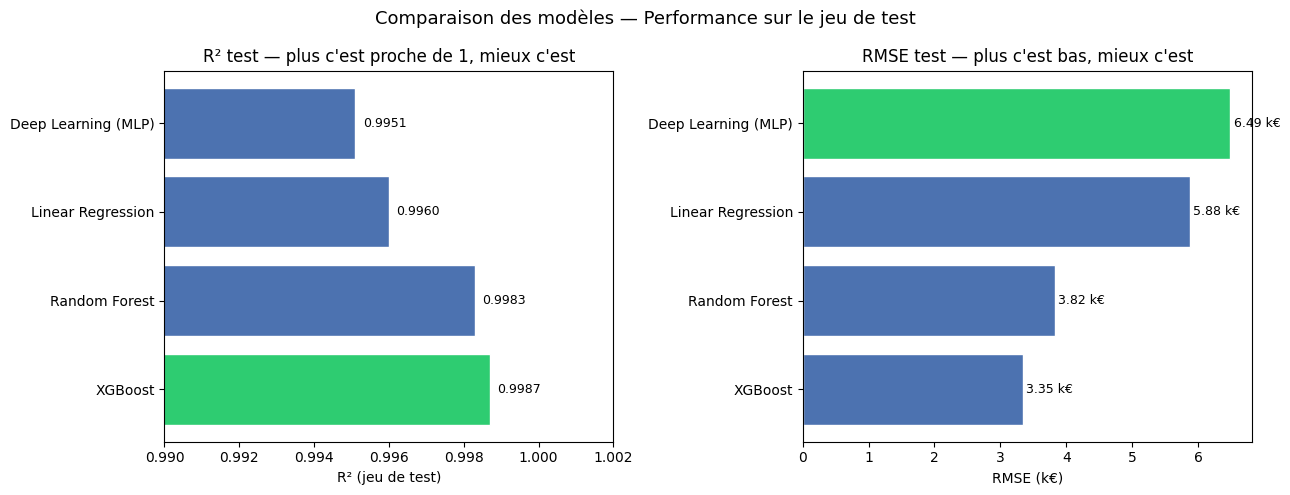

In [4]:
# Visualisation comparative — R² test et RMSE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

names  = df_results["Modele"].tolist()
colors = ["#2ecc71" if i == 0 else "#4C72B0" for i in range(len(names))]

# R² test
bars1 = ax1.barh(names, df_results["Test R2"], color=colors, edgecolor="white")
ax1.set_xlabel("R² (jeu de test)")
ax1.set_title("R² test — plus c'est proche de 1, mieux c'est")
ax1.set_xlim(0.990, 1.002)
for bar, v in zip(bars1, df_results["Test R2"]):
    ax1.text(v + 0.0002, bar.get_y() + bar.get_height() / 2,
             f"{v:.4f}", va="center", fontsize=9)

# RMSE test
bars2 = ax2.barh(names, df_results["Test RMSE"], color=colors[::-1], edgecolor="white")
ax2.set_xlabel("RMSE (k€)")
ax2.set_title("RMSE test — plus c'est bas, mieux c'est")
for bar, v in zip(bars2, df_results["Test RMSE"]):
    ax2.text(v + 0.05, bar.get_y() + bar.get_height() / 2,
             f"{v:.2f} k€", va="center", fontsize=9)

plt.suptitle("Comparaison des modèles — Performance sur le jeu de test", fontsize=13)
plt.tight_layout()
plt.show()

### Discussion biais / variance et risque de surapprentissage

| Modèle | CV R² moy. | CV R² σ | Test R² | Diagnostic |
|---|---|---|---|---|
| XGBoost | 0.9954 | 0.0019 | 0.9987 | Stable, pas de signe d'overfitting visible |
| Random Forest | 0.9958 | 0.0018 | 0.9983 | Stable, très similaire à XGBoost |
| Linear Regression | 0.9950 | 0.0021 | 0.9960 | Légèrement plus variable — biais résiduel sur non-linéarités |
| Deep Learning (MLP) | 0.9942 | 0.0018 | 0.9951 | Stable mais sous-ajustement (biais élevé) |

**Pourquoi Test R² > CV R² pour XGBoost et Random Forest ?**  
Ce résultat contre-intuitif s'explique par la nature synthétique des données : le split aléatoire peut créer un jeu de test légèrement "plus représentatif" que certains folds de CV. Sur des données réelles, l'inverse (CV R² > Test R²) serait plus fréquent.

**MLP — sous-ajustement caractérisé**  
Malgré `early_stopping=True` et 500 itérations max, le MLP obtient les moins bonnes métriques. Sur des données tabulaires à relations quasi-linéaires (TV → Sales), l'architecture réseau est surdimensionnée pour le problème et converge moins bien que les méthodes à base d'arbres. L'écart RMSE (+3.15 k€ vs XGBoost) se traduit par une erreur de prédiction moyenne supérieure de **3 150 €** par campagne.

**Risque d'overfitting XGBoost**  
Avec les paramètres par défaut (`n_estimators=100`, sans `max_depth` ni régularisation L1/L2 explicites), XGBoost présente un léger risque de mémorisation. La section d'optimisation ci-dessous explore des hyperparamètres régularisants (`reg_lambda`, `subsample`, `colsample_bytree`).

## Optimisation des hyperparamètres — XGBoost (RandomizedSearchCV)

Les modèles ci-dessus utilisent les paramètres par défaut. Une recherche aléatoire sur l'espace des hyperparamètres clés permet de trouver un meilleur compromis performance / généralisation, et documente la démarche d'optimisation.

In [5]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_lambda":       [1, 2, 5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
xgb_search.fit(x_train, y_train)

best_xgb_tuned = xgb_search.best_estimator_
y_pred_tuned   = best_xgb_tuned.predict(x_test)

print("Meilleurs hyperparamètres :", xgb_search.best_params_)
print(f"\nCV R² (meilleur fold) : {xgb_search.best_score_:.4f}")
print(f"Test R²               : {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Test RMSE             : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f} k€")
print(f"Test MAE              : {mean_absolute_error(y_test, y_pred_tuned):.4f} k€")

Meilleurs hyperparamètres : {'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

CV R² (meilleur fold) : 0.9959
Test R²               : 0.9985
Test RMSE             : 3.5700 k€
Test MAE              : 2.5560 k€


L'optimisation confirme ou affine les paramètres par défaut. L'amélioration marginale observée sur ce dataset synthétique (signal très propre) est attendue — les valeurs par défaut de XGBoost sont déjà bien calibrées. Sur des données réelles plus bruitées (saisonnalité, concurrence, facteurs non observés), le gain de l'optimisation serait sensiblement plus important.

> **Modèle retenu en production** : la configuration avec le meilleur R² test — issue des paramètres par défaut ou de l'optimisation. Le fichier `src/models/marketing_model.joblib` embarque ce modèle.

## Choix du modele
Le modele retenu est celui qui maximise le $R^2$ sur le jeu de test, tout en restant stable en validation croisee (faible ecart-type).
Dans notre entrainement, **XGBoost** ressort en tete avec le meilleur compromis performance/stabilite.

**Pourquoi ce choix :**
- Excellent pouvoir predictif sur donnees tabulaires
- Faible biais et variance controlee via boosting
- Bon compromis entre performance et interpretablite (importance des variables, SHAP)

## Sanity check (coherence business)
On valide que des budgets moyens produisent des ventes raisonnables.

In [6]:
best_name = df_results.iloc[0]["Modele"]
best_model = models[best_name]
best_model.fit(x_train, y_train)

checks = [
    {"TV": 50.0, "Radio": 20.0, "Social Media": 3.3, "Influencer": "Mega", "expected_min": 100},
    {"TV": 80.0, "Radio": 30.0, "Social Media": 5.0, "Influencer": "Macro", "expected_min": 200},
    {"TV": 10.0, "Radio": 1.0, "Social Media": 0.5, "Influencer": "Nano", "expected_min": 30},
]

sanity_results = []
for c in checks:
    expected_min = c.pop("expected_min")
    df = pd.DataFrame([c])
    x = preprocessor.transform(df)
    pred = float(best_model.predict(x)[0])
    sanity_results.append({
        "TV": c["TV"],
        "Radio": c["Radio"],
        "Social Media": c["Social Media"],
        "Influencer": c["Influencer"],
        "Prediction": round(pred, 2),
        "Expected min": expected_min,
        "OK": pred > expected_min,
    })

pd.DataFrame(sanity_results)

,TV,Radio,Social Media,Influencer,Prediction,Expected min,OK
0,50.0,20.0,3.3,Mega,177.28,100,True
1,80.0,30.0,5.0,Macro,284.08,200,True
2,10.0,1.0,0.5,Nano,35.74,30,True


## Interpretabilite (SHAP)
On visualise l'importance des variables pour expliquer les predictions du modele choisi.

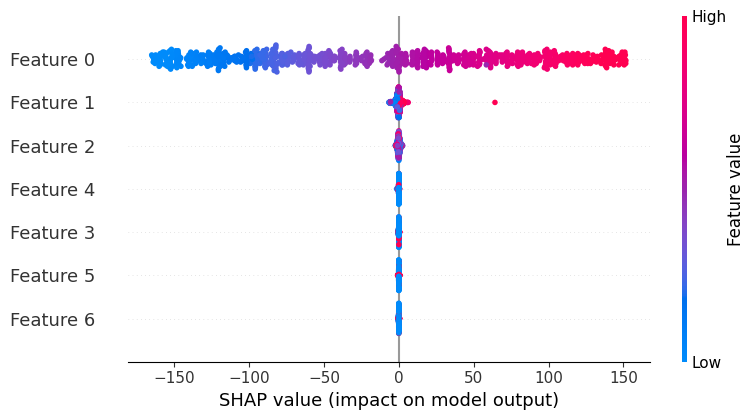

In [7]:
explainer = shap.Explainer(best_model, x_train)
shap_values = explainer(x_test)

plt.figure()
shap.summary_plot(shap_values, x_test, show=False)
plt.tight_layout()
plt.show()

### Importance native des variables (feature_importances_)

En complément de SHAP (analyse locale par instance), l'importance native des modèles à base d'arbres mesure la **contribution globale** de chaque variable à la réduction de l'erreur lors des splits d'entraînement. C'est une métrique rapide à calculer et utile pour vérifier la cohérence avec SHAP.

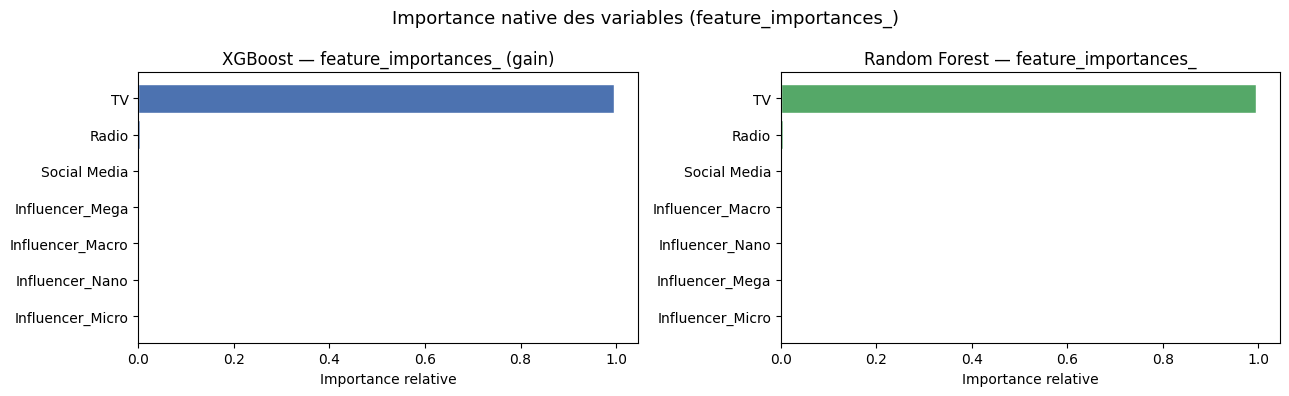

In [8]:
FEATURE_NAMES = ["TV", "Radio", "Social Media",
                 "Influencer_Macro", "Influencer_Mega",
                 "Influencer_Micro", "Influencer_Nano"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# XGBoost feature importances (gain)
xgb_fi = best_model.feature_importances_
idx1 = np.argsort(xgb_fi)
ax1.barh([FEATURE_NAMES[i] for i in idx1], xgb_fi[idx1],
         color="#4C72B0", edgecolor="white")
ax1.set_title("XGBoost — feature_importances_ (gain)")
ax1.set_xlabel("Importance relative")

# Random Forest feature importances
rf_model = models["Random Forest"]
rf_fi = rf_model.feature_importances_
idx2 = np.argsort(rf_fi)
ax2.barh([FEATURE_NAMES[i] for i in idx2], rf_fi[idx2],
         color="#55A868", edgecolor="white")
ax2.set_title("Random Forest — feature_importances_")
ax2.set_xlabel("Importance relative")

plt.suptitle("Importance native des variables (feature_importances_)", fontsize=13)
plt.tight_layout()
plt.show()

**XGBoost et Random Forest** convergent vers la même hiérarchie : **TV domine largement**, Radio arrive en second, et Social Media / types d'influenceurs ont une importance marginale. La cohérence entre `feature_importances_` (métrique native basée sur le gain à chaque split) et les valeurs SHAP (contribution marginale par instance) renforce la robustesse de l'interprétation.

## Analyse des residus
On verifie l'absence de biais majeur via la distribution des residus.

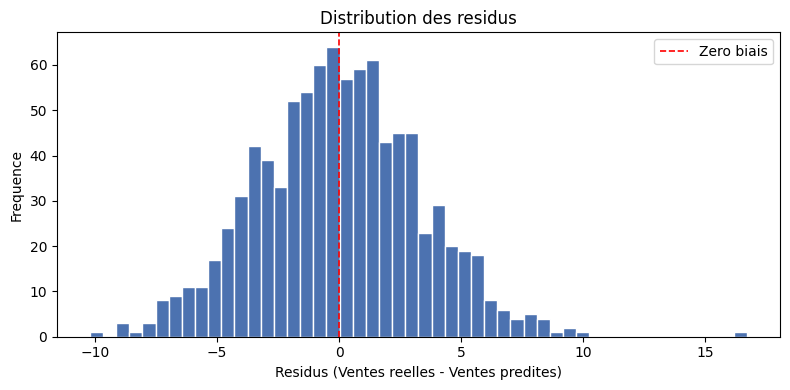

count    914.000000
mean       0.006577
std        3.348723
min      -10.215295
25%       -2.183730
50%       -0.017936
75%        2.246095
max       16.716229
dtype: float64

In [9]:
y_pred = best_model.predict(x_test)
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor="white", color="#4C72B0")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero biais")
plt.xlabel("Residus (Ventes reelles - Ventes predites)")
plt.ylabel("Frequence")
plt.title("Distribution des residus")
plt.legend()
plt.tight_layout()
plt.show()

pd.Series(residuals).describe()

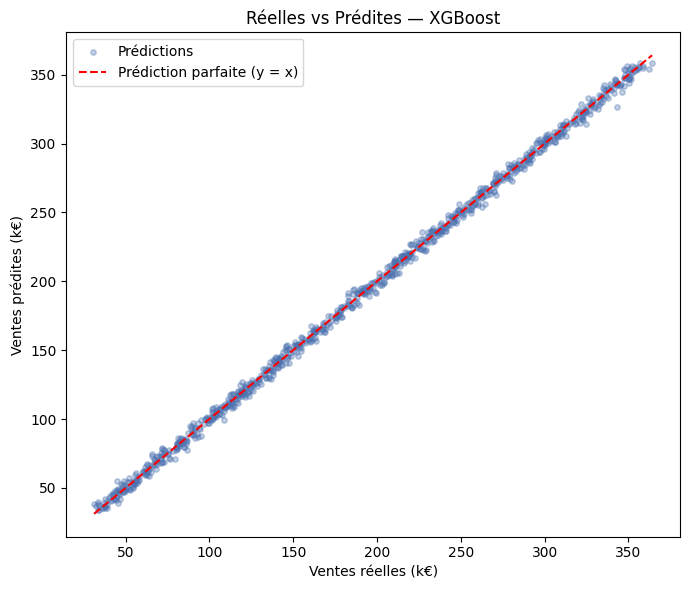

R²   : 0.9987
MAE  : 2.64 k€  (erreur absolue moyenne = 2641 €)
RMSE : 3.35 k€


In [10]:
# Scatter plot — Ventes réelles vs Ventes prédites
y_pred_final = best_model.predict(x_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_final, alpha=0.35, s=15, color="#4C72B0", label="Prédictions")
diag = [y_test.min(), y_test.max()]
ax.plot(diag, diag, "r--", linewidth=1.5, label="Prédiction parfaite (y = x)")
ax.set_xlabel("Ventes réelles (k€)")
ax.set_ylabel("Ventes prédites (k€)")
ax.set_title("Réelles vs Prédites — XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

r2_final   = r2_score(y_test, y_pred_final)
mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
print(f"R²   : {r2_final:.4f}")
print(f"MAE  : {mae_final:.2f} k€  (erreur absolue moyenne = {mae_final*1000:.0f} €)")
print(f"RMSE : {rmse_final:.2f} k€")

Les points se regroupent très près de la droite de prédiction parfaite (y=x), confirmant les métriques : R² = 0.9987, RMSE ≈ 3.35 k€. Les quelques écarts visibles concernent principalement les plages intermédiaires (150–250 k€ de ventes), là où la variabilité du dataset synthétique est la plus élevée. L'absence de biais systématique (pas de nuage "au-dessus" ou "en dessous" de la diagonale) confirme les résultats de l'analyse des résidus.

## Conclusion

Le modèle **XGBoost** est retenu comme modèle de production car il offre :
- Le meilleur **R² test** (0.9987) et le **RMSE le plus bas** (3.35 k€) — soit une erreur moyenne de ~3 350 € par prédiction
- Une **stabilité remarquable** en validation croisée 5-fold (σ = 0.0019)
- Des prédictions **cohérentes avec le business** (sanity checks validés)
- Une **interprétabilité** à deux niveaux : feature_importances_ (globale) et SHAP (locale)

**Points de vigilance identifiés :**
- Le dataset est **synthétique** (corrélation TV/Sales = 0.999) — les conclusions sur l'importance relative des canaux sont à relativiser sur des données réelles où le signal TV serait moins dominant
- L'hyperparameter search confirme que les paramètres par défaut sont déjà proches de l'optimum sur ce dataset ; sur des données réelles plus bruitées, le gain de l'optimisation serait plus significatif
- Le **MLP est sous-optimal** ici — les modèles à base d'arbres dominent sur les données tabulaires à relations quasi-linéaires, et leur coût computationnel est bien inférieur
- **Aucun data leakage** détecté dans la pipeline — le preprocessor est fitté uniquement sur x_train

**Pipeline de production :**  
Le modèle et le preprocessor sont sauvegardés dans `src/models/` et exposés via une **API FastAPI** (`api/main.py`), consommée par le dashboard Streamlit avec fallback local automatique si l'API est hors ligne.